In [1]:
!bash -lc 'module load Miniforge3/24.1.2-0 && source $EBROOTMINIFORGE3/bin/activate && conda activate hycom-cice'
import xarray as xr

The following modules were not unloaded:
  (Use "module --force purge" to unload all):

  1) StdEnv


In [2]:
#varlist = ["templvl"]
varlist = ["templvl","salnlvl","no3lvl","silvl","o2lvl","dissiclvl","talklvl","po4lvl","sealv"]
DATA_PATH = "/cluster/projects/nn9481k/arnaud/Script-tools/SEACLIM/NorCPM_bias/"

filelist = [DATA_PATH+"bias_NorCPM_REFRUN_64M_"+var+".nc" for var in varlist]

ds = xr.open_mfdataset(filelist, combine="by_coords", use_cftime=True, chunks={"time": 1})

/tmp/ipykernel_837149/1743402791.py:7: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(filelist, combine="by_coords", use_cftime=True, chunks={"time": 1})
/tmp/ipykernel_837149/1743402791.py:7: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(filelist, combine="by_coords", use_cftime=True, chunks={"time": 1})
/tmp/ipykernel_837149/1743402791.py:7: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance

In [3]:
ds

<xarray.Dataset> Size: 20GB
Dimensions:    (time: 64, depth: 70, y: 385, x: 360)
Coordinates:
  * time       (time) object 512B 1999-11-15 00:00:00 ... 2005-02-15 00:00:00
  * depth      (depth) float64 560B 0.0 5.0 10.0 ... 6.25e+03 6.5e+03 6.75e+03
    lon        (y, x) float64 1MB dask.array<chunksize=(385, 360), meta=np.ndarray>
    lat        (y, x) float64 1MB dask.array<chunksize=(385, 360), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    templvl    (time, depth, y, x) float32 2GB dask.array<chunksize=(1, 70, 385, 360), meta=np.ndarray>
    salnlvl    (time, depth, y, x) float32 2GB dask.array<chunksize=(1, 70, 385, 360), meta=np.ndarray>
    no3lvl     (time, depth, y, x) float32 2GB dask.array<chunksize=(1, 70, 385, 360), meta=np.ndarray>
    silvl      (time, depth, y, x) float32 2GB dask.array<chunksize=(1, 70, 385, 360), meta=np.ndarray>
    o2lvl      (time, depth, y, x) float32 2GB dask.array<chunksize=(1, 70, 385, 360), meta=np.ndarray>
    dissiclvl  (time, depth, y, x) float32 2GB dask.array<chunksize=(1, 70, 385, 360), meta=np.ndarray>
    talklvl    (time, depth, y, x) float32 2GB dask.array<chunksize=(1, 70, 385, 360), meta=np.ndarray>
    po4lvl     (time, depth, y, x) float32 2GB dask.array<chunksize=(1, 70, 385, 360), meta=np.ndarray>
    sealv      (time, y, x) float32 35MB dask.array<chunksize=(1, 385, 360), meta=np.ndarray>

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import TwoSlopeNorm

def ArcticMap():

    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw={"projection": ccrs.NorthPolarStereo(central_longitude=0.0)},
    )

    ax.set_extent([-180, 180, 48, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor=cfeature.COLORS["land"], edgecolor="grey", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="grey", linewidth=0.4, zorder=3)
    ax.gridlines()
      
    return fig, ax
    
def pcolormesh_curvilinear(lon, lat, data, ax=None, **kwargs):

    proj = ax.projection
    pxy = proj.transform_points(ccrs.PlateCarree(), lon, lat)
    px, py = pxy[:, :, 0], pxy[:, :, 1]
    invalid = ~np.isfinite(px) | ~np.isfinite(py)
    px = np.where(invalid, 0.0, px)
    py = np.where(invalid, 0.0, py)
    data = np.where(invalid, np.nan, data)
    return ax.pcolormesh(px, py, data, **kwargs)


<Figure size 640x480 with 0 Axes>

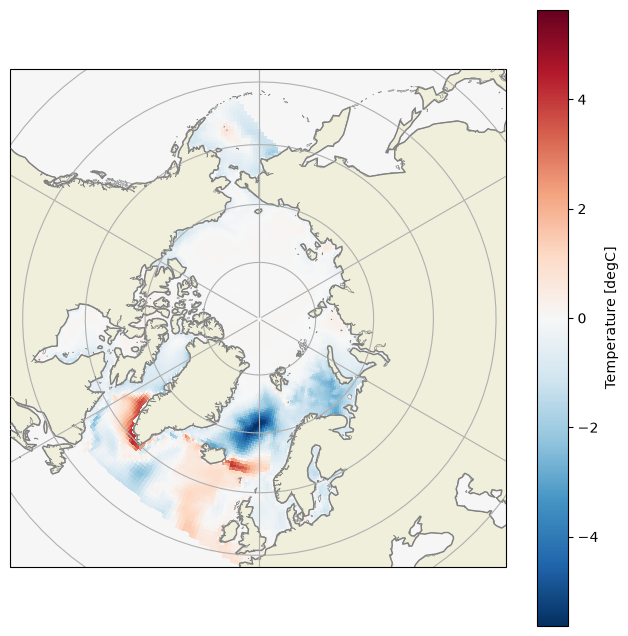

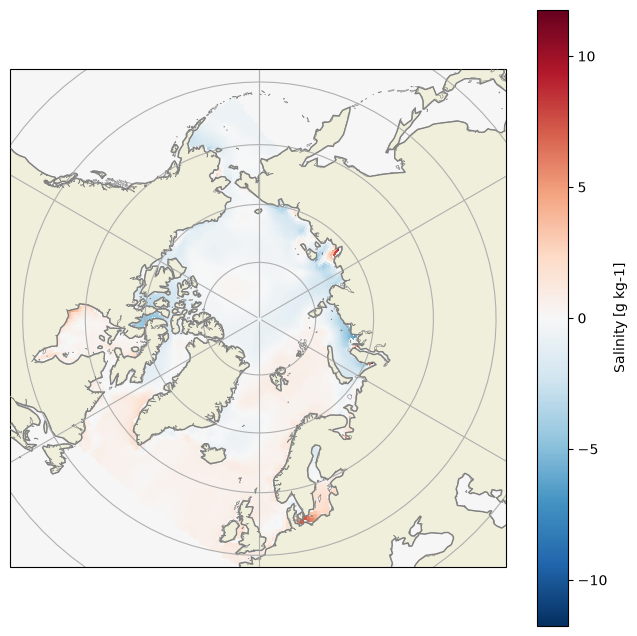

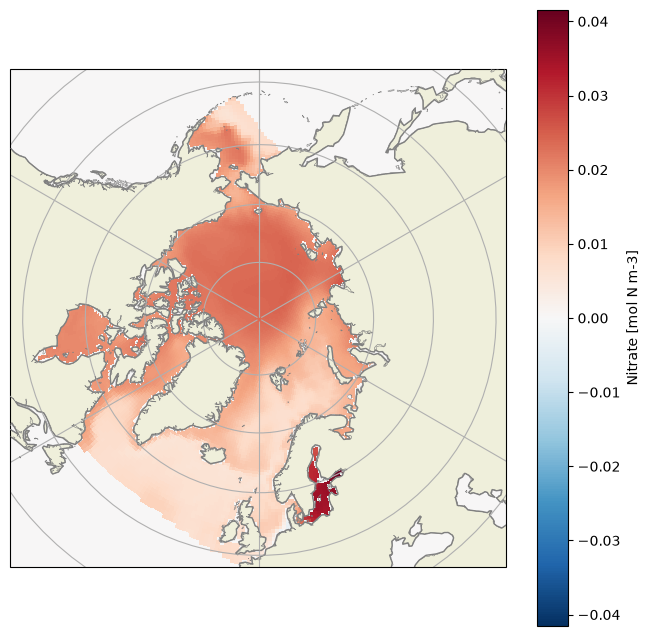

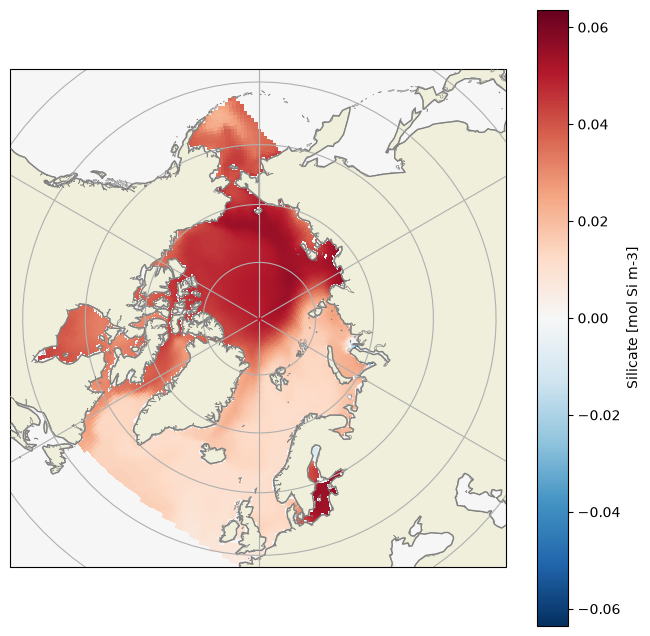

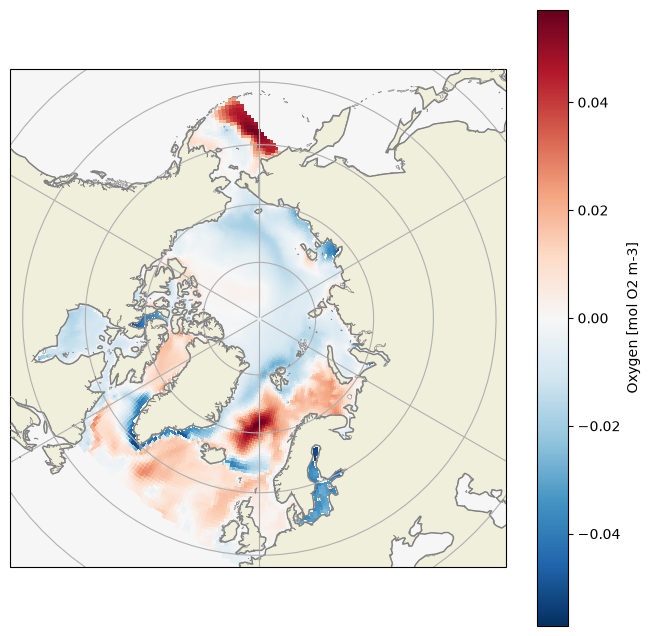

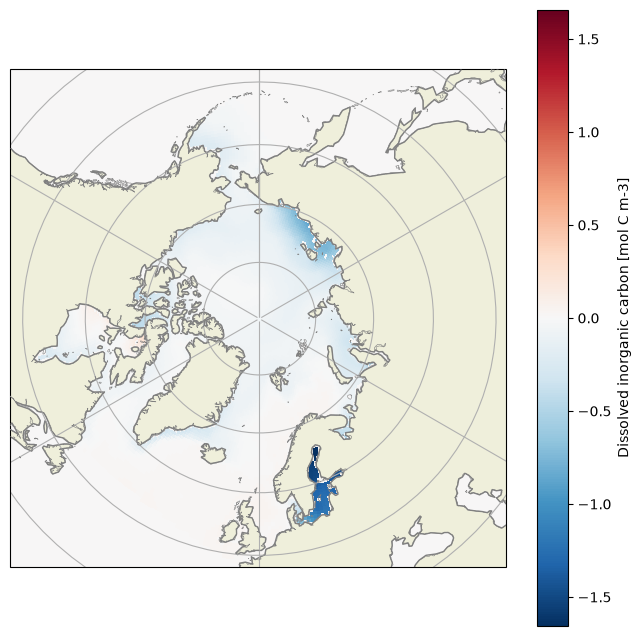

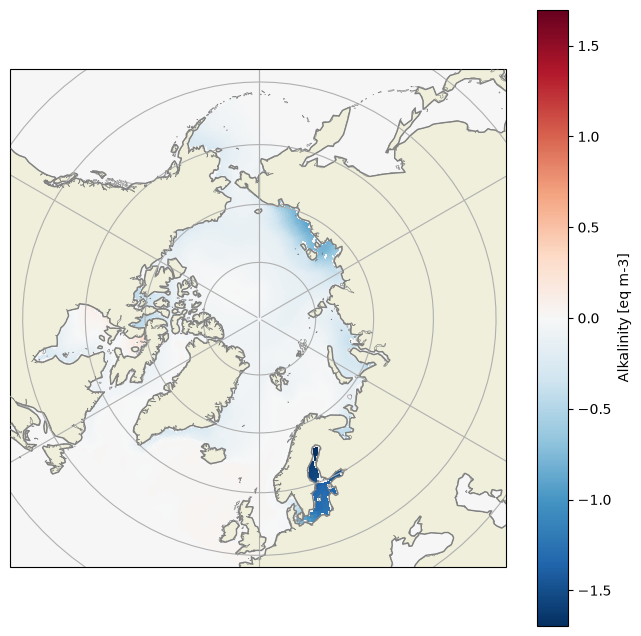

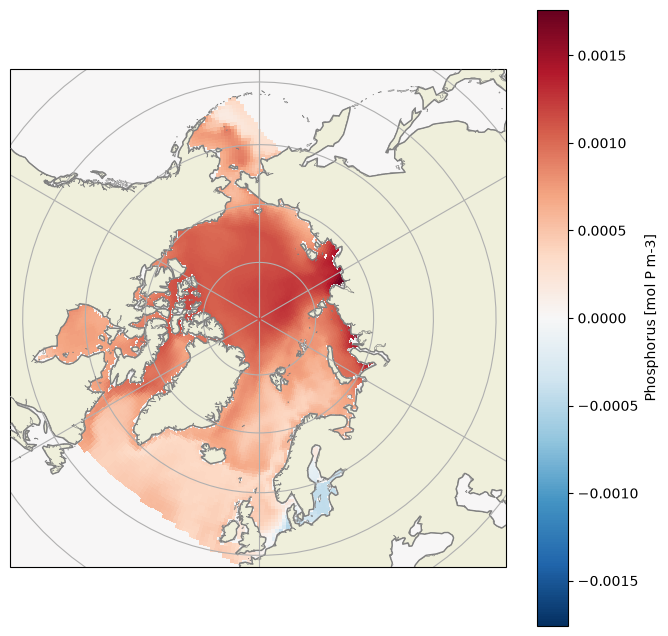

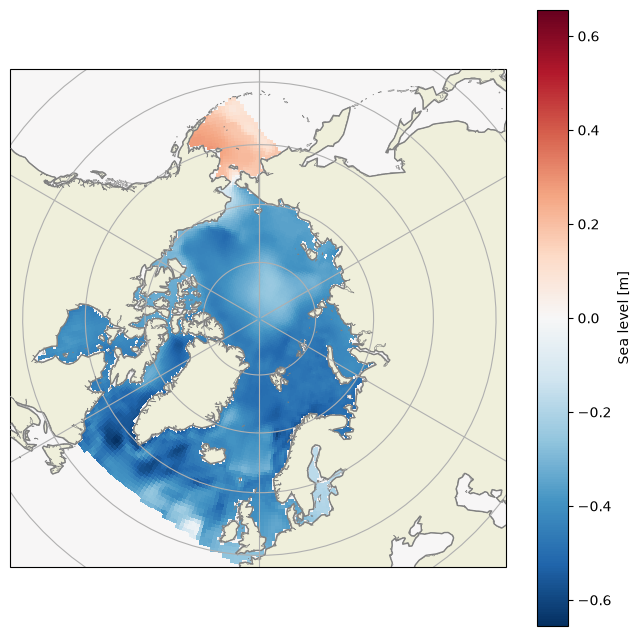

In [5]:
for (i,var) in enumerate(varlist):
    if var == "sealv":
        temp = ds[var].mean(dim="time")
    else:
        temp = ds[var].isel(depth=0).mean(dim="time")
    plt.figure(i)
    fig, ax = ArcticMap()
    vmax = np.nanmax(np.abs(temp.values))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    p = pcolormesh_curvilinear(temp.lon.values, temp.lat.values, temp.values, ax=ax, cmap="RdBu_r", norm=norm)
    fig.colorbar(p, ax=ax, label=f"{temp.attrs['long_name']} [{temp.attrs['units']}]")

Atlantic West   : j= 301, i=  60, grid=(55.22°, 310.03°)
Atlantic East   : j= 298, i=  89, grid=(54.00°, 339.49°)
Pacific         : j= 306, i= 291, grid=(58.17°, 182.17°)


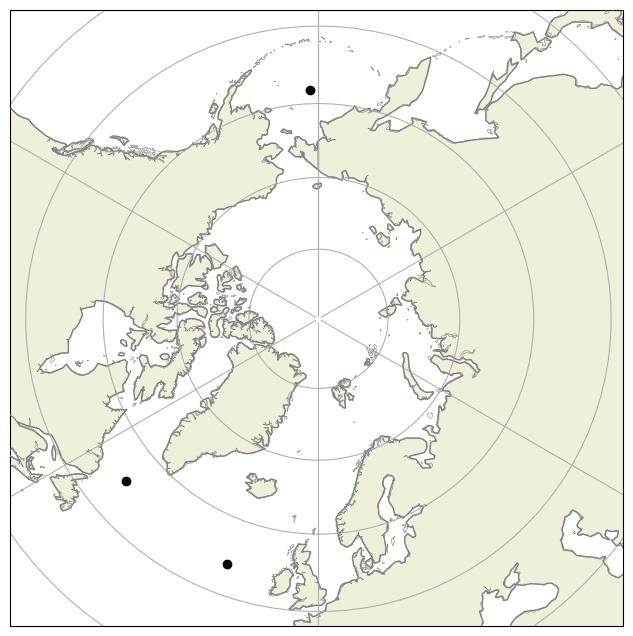

In [6]:
"""POINTS = {
    "Iceland Basin": {"lat": 62.0, "lon": -20.0},
    "Norwegian Sea": {"lat": 68.0, "lon":   5.0},
    "Fram Strait":   {"lat": 79.0, "lon":   0.0},
}"""
POINTS = {
    "Atlantic West": {"lat": 55.0, "lon": -50.0},
    "Atlantic East": {"lat": 54.0, "lon": -20.0},
    "Pacific": {"lat": 58.0, "lon": -178.0},
}

lon = ds["lon"].values   # shape (j,i)
lat = ds["lat"].values    # shape (j,i)

point_idx = {}
fig, ax = ArcticMap()

for name, p in POINTS.items():
    dist2 = (lon - (p["lon"]%360))**2 + (lat - p["lat"])**2
    j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)

    point_idx[name] = (j, i)

    print(
        f"{name:16s}: j={j:4d}, i={i:4d}, "
        f"grid=({lat[j,i]:.2f}°, {lon[j,i]:.2f}°)"
    )
    plt.plot(lon[j,i],lat[j,i],"ko",transform=ccrs.PlateCarree())

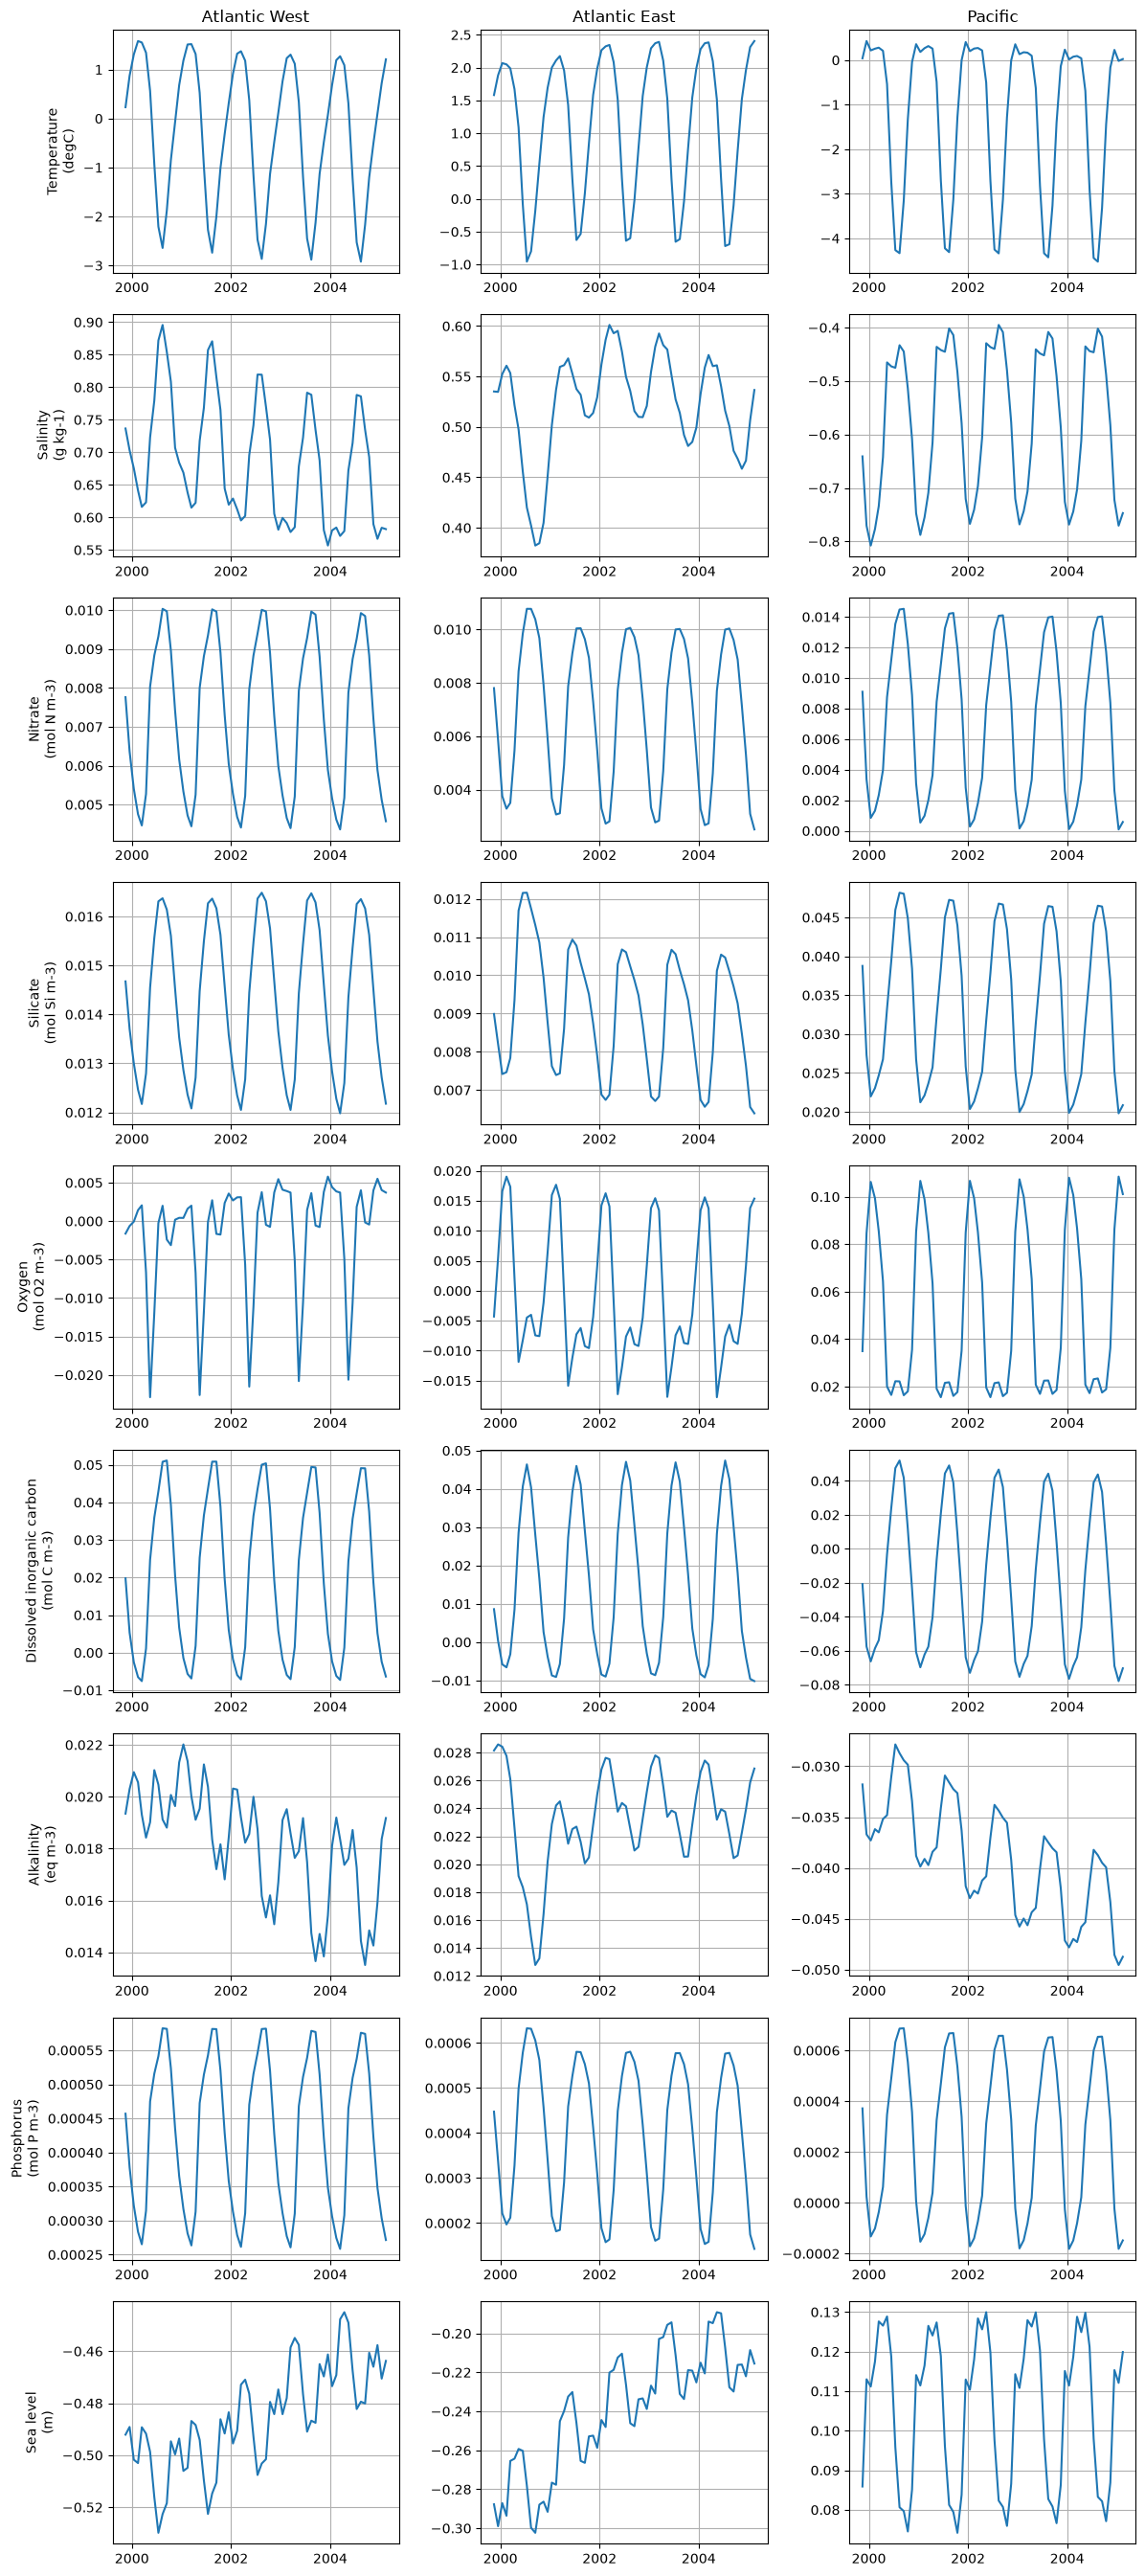

In [7]:
nrows = len(varlist)       # variables
ncols = len(point_idx)     # locations

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4*ncols, 3*nrows),
    squeeze=False
)

for col, (name, (y, x)) in enumerate(point_idx.items()):
    for row, var in enumerate(varlist):

        ax = axes[row, col]

        if var == "sealv":
            temp = ds[var].isel(y=y, x=x)
        else:
            temp = ds[var].isel(y=y, x=x, depth=0)

        temp.plot(ax=ax)

        ax.grid(True)

        # Column titles = locations
        if row == 0:
            ax.set_title(name)
        else:
            ax.set_title("")

        # Row labels = variables
        if col == 0:
            ax.set_ylabel(f"{temp.long_name}\n({temp.units})")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [8]:
from glob import glob
import cftime

NORCPM_PATH = "/cluster/projects/nn9481k/arnaud/Script-tools/SEACLIM/norcpm_clim/"
REFRUN_PATH = "/cluster/work/users/arnelt/clim_ave/"

filelist_norcpm = sorted(glob(NORCPM_PATH + "noresm2-mm-seaclim*"))
filelist_refrun = sorted(glob(REFRUN_PATH + "clim_1993_2024_*"))

common_time = [
    cftime.DatetimeNoLeap(1999, m, 15)
    for m in range(11, 13)
] + [
    cftime.DatetimeNoLeap(y, m, 15)
    for y in range(2000,2005)
    for m in range(1, 13)
] + [
    cftime.DatetimeNoLeap(2005, m, 15)
    for m in range(1, 3)
]

norcpm_datasets = []

for f in filelist_norcpm:
    ds_temp = xr.open_dataset(f, use_cftime=True)

    if "depth_bnds" in ds_temp.variables:
        ds_temp = ds_temp.drop_vars("depth_bnds")
    if ds_temp.attrs.get("bounds") is not None:
        ds_temp["depth"].attrs.pop("bounds")

    # Replace the existing time coordinate
    ds_temp = ds_temp.assign_coords(time=common_time)

    norcpm_datasets.append(ds_temp)

ds_norcpm = xr.merge(norcpm_datasets)
ds_refrun = xr.open_mfdataset(filelist_refrun, combine="by_coords", use_cftime=True, chunks={"time": 1})

ds_refrun = xr.concat([ds_refrun] * 7, dim="time")
ds_refrun = ds_refrun.isel(time=slice(10, 74))

ds_refrun = ds_refrun.assign_coords(time=common_time)

rename_dict = {
    "thetao":"templvl",
    "so":"salnlvl",
    "no3":"no3lvl",
    "si":"silvl",
    "o2":"o2lvl",
    "dissic":"dissiclvl",
    "TA":"talklvl",
    "po4":"po4lvl",
    "zos":"sealv"
}
ds_refrun = ds_refrun.rename(rename_dict)

/tmp/ipykernel_837149/1995242087.py:25: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds_temp = xr.open_dataset(f, use_cftime=True)
/cluster/projects/nn9481k/conda/arnelt/hycom-cice/lib/python3.11/site-packages/xarray/coding/times.py:383: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/tmp/ipykernel_837149/1995242087.py:25: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds_temp = xr.open

<Figure size 640x480 with 0 Axes>

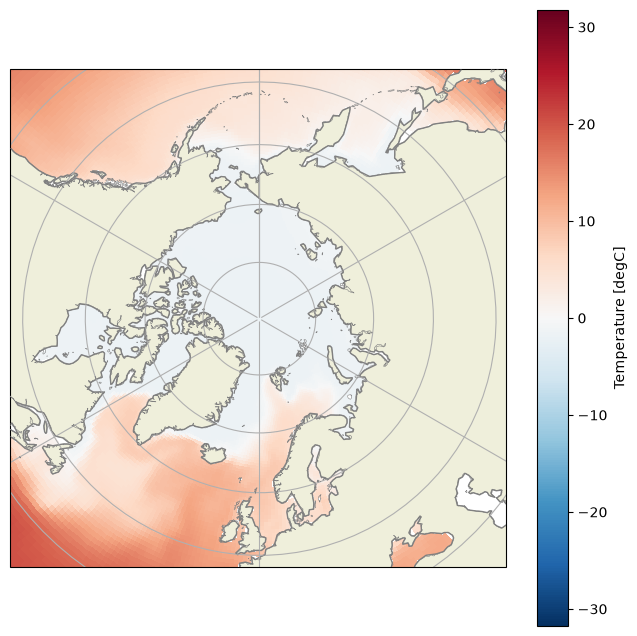

In [9]:
#ds_norcpm
#ds_refrun
temp = ds_norcpm["templvl"].isel(depth=0, time=2)
plt.figure(i)
fig, ax = ArcticMap()
vmax = np.nanmax(np.abs(temp.values))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
p = pcolormesh_curvilinear(temp.lon.values, temp.lat.values, temp.values, ax=ax, cmap="RdBu_r", norm=norm)
fig.colorbar(p, ax=ax, label=f"{temp.attrs['long_name']} [{temp.attrs['units']}]")

Atlantic West   : j=  11, i= 192, grid=(54.98°, -49.94°)
Atlantic East   : j=  12, i= 287, grid=(53.96°, -19.87°)
Pacific         : j= 367, i=  56, grid=(57.94°, -177.95°)


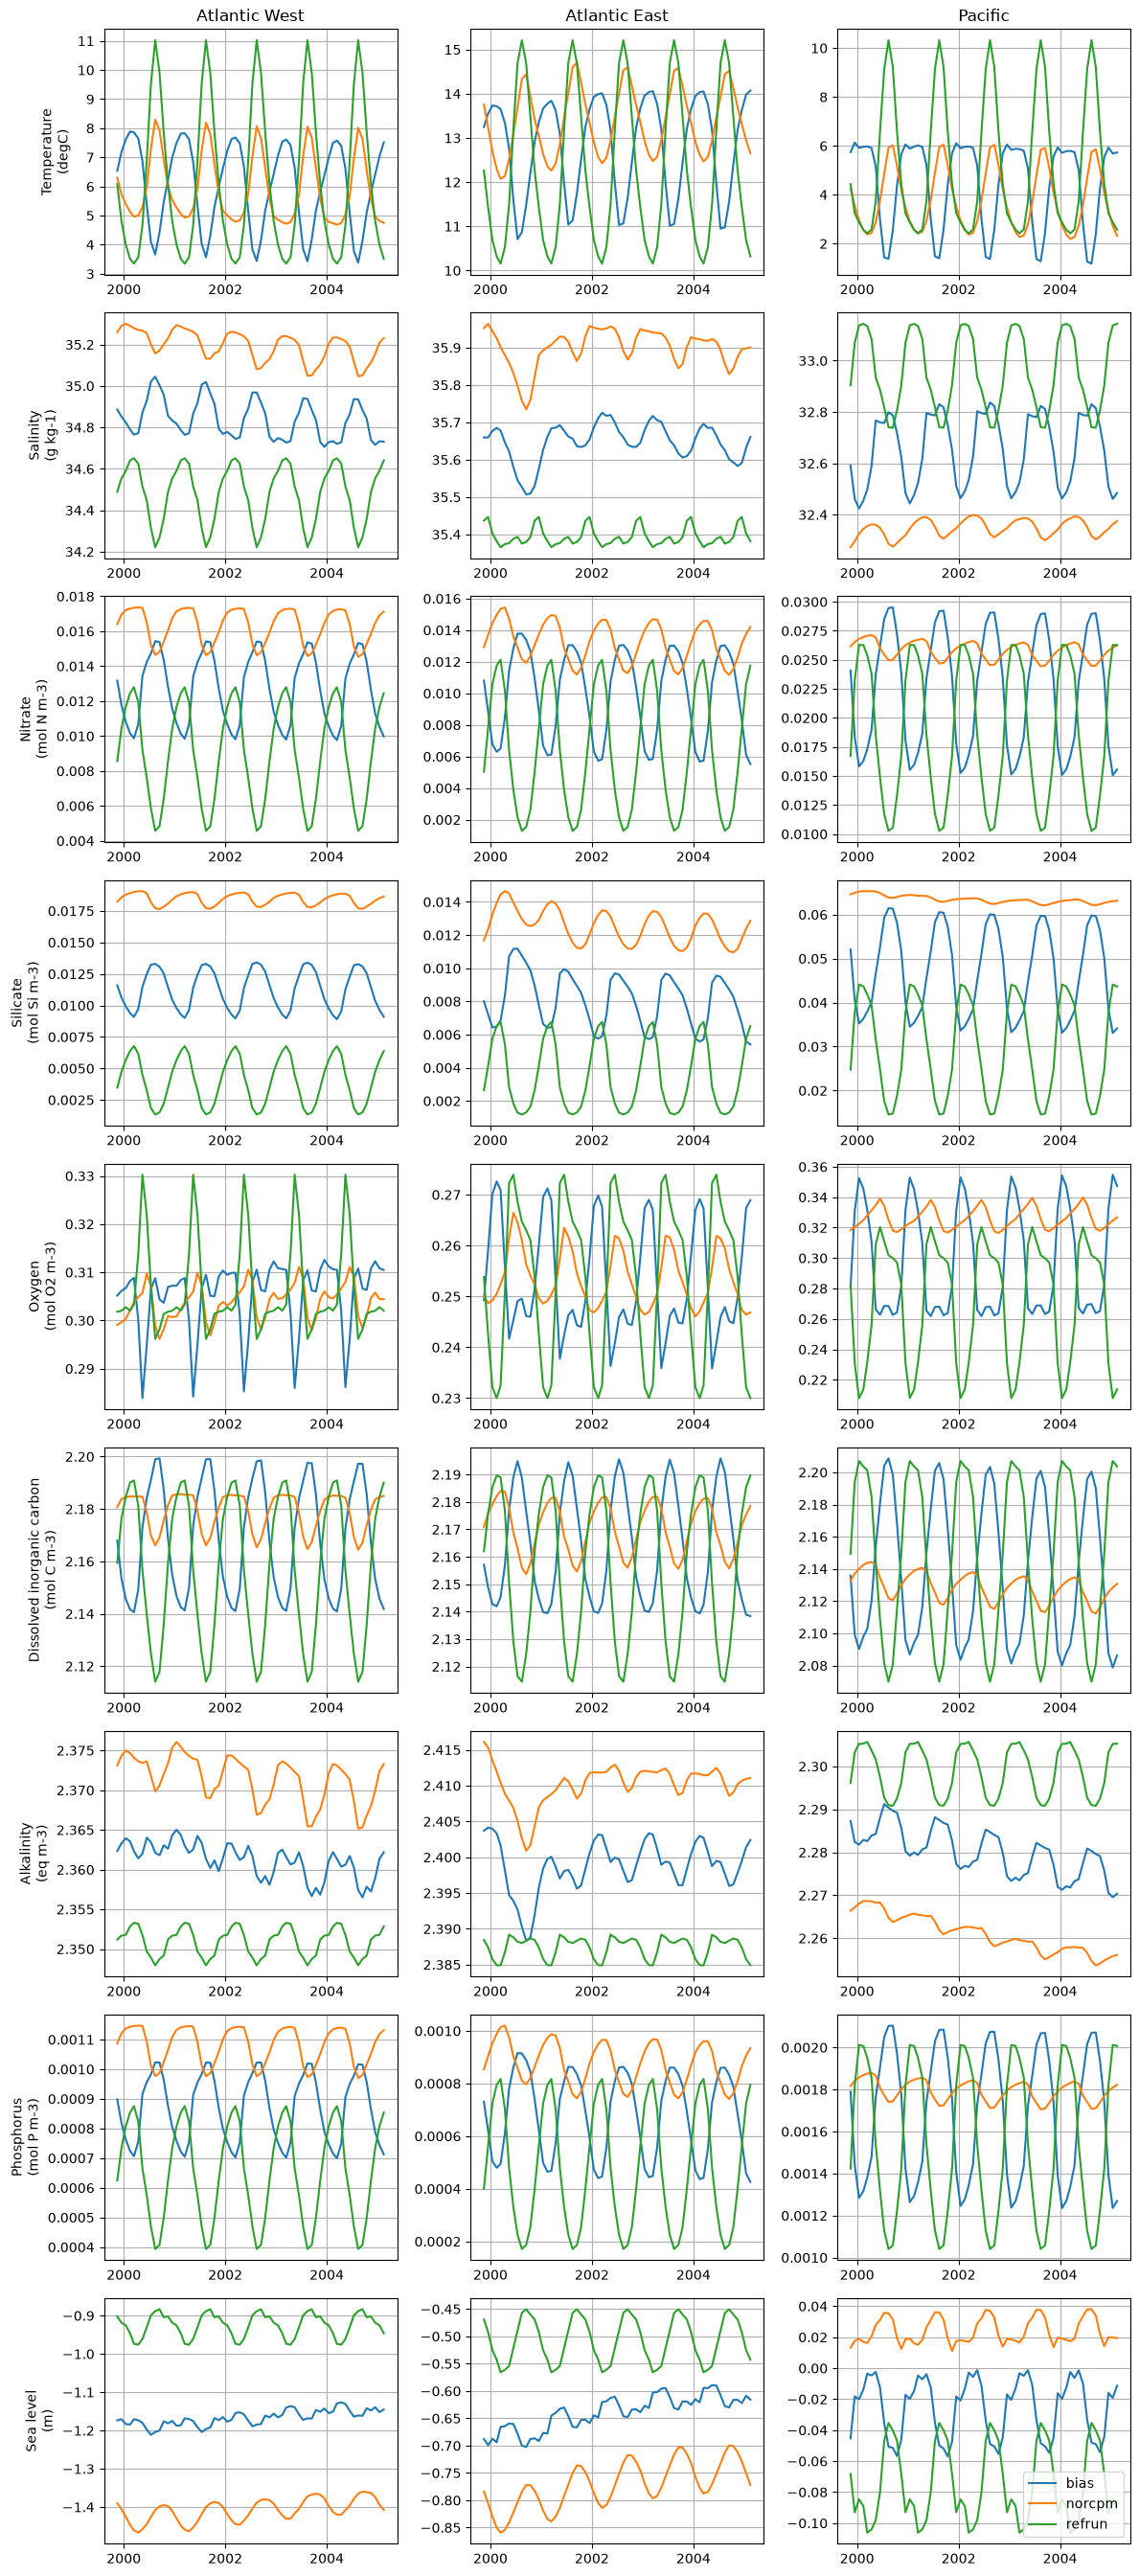

In [11]:
point_idx_refrun = {}
lon2 = ds_refrun["longitude"].isel(time=0).values
lat2 = ds_refrun["latitude"].isel(time=0).values

for name, p in POINTS.items():
    dist2 = np.minimum(np.abs((lon2 % 360) - (p["lon"] % 360)), 360 - np.abs((lon2 % 360) - (p["lon"] % 360)))**2 + (lat2 - p["lat"])**2
    j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)

    point_idx_refrun[name] = (j, i)

    print(
        f"{name:16s}: j={j:4d}, i={i:4d}, "
        f"grid=({lat2[j,i]:.2f}°, {lon2[j,i]:.2f}°)"
    )

nrows = len(varlist)       # variables
ncols = len(point_idx)     # locations

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4*ncols, 3*nrows),
    squeeze=False
)

ds2 = ds.assign_coords(time=common_time)

for col, (name, (y, x)) in enumerate(point_idx.items()):
    for row, var in enumerate(varlist):

        ax = axes[row, col]

        if var == "sealv":
            temp = ds2[var].isel(y=y, x=x)
            temp1 = ds_norcpm[var].isel(y=y, x=x)
            temp2 = ds_refrun[var].isel(y=point_idx_refrun[name][0], x=point_idx_refrun[name][1])
        else:
            temp = ds2[var].isel(y=y, x=x, depth=0)
            temp1 = ds_norcpm[var].isel(y=y, x=x, depth=0)
            temp2 = ds_refrun[var].isel(y=point_idx_refrun[name][0], x=point_idx_refrun[name][1], depth=0)

        if var in ["o2lvl","no3lvl","po4lvl","silvl"]:
            temp2 *= 0.001

        temp = temp + temp1.mean()/2 + temp2.mean()/2 - temp.mean()
        temp3 = temp1 - temp2
        temp3 = temp3 + temp1.mean()/2 + temp2.mean()/2 - temp3.mean()
        
        temp.plot(ax=ax, label="bias")
        temp1.plot(ax=ax, label="norcpm")
        temp2.plot(ax=ax, label="refrun")
        #temp3.plot(ax=ax, label="difference")

        ax.grid(True)

        # Column titles = locations
        if row == 0:
            ax.set_title(name)
        else:
            ax.set_title("")

        # Row labels = variables
        if col == 0:
            ax.set_ylabel(f"{temp1.long_name}\n({temp1.units})")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")

plt.tight_layout()
plt.legend()
plt.show()